# Bank Marketing Campaign ROI Analysis
### Who to Call, When to Call, and Why It Matters

**Author:** [Your Name]  
**Date:** March 2026

**Objective:** Analyze a Portuguese bank's direct marketing campaign data to identify which customers are most likely to subscribe to a term deposit, optimize campaign strategy, and quantify the ROI impact of targeted marketing.

**Dataset:** Bank Marketing Dataset (45,211 records) — phone-based campaign data with customer demographics, campaign details, and subscription outcomes.

---
## Part 1: Setup & Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
# Note: This CSV uses semicolons (;) as separators, not commas
df = pd.read_csv('data/raw/bank-full.csv', sep=';')

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset shape: 45211 rows x 17 columns


Memory usage: 25.75 MB


In [3]:
# First look at the data
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Last 5 rows
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
# Statistical summary for numeric columns
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
# Statistical summary for categorical columns
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [8]:
# Check column names and unique values count
print("Column names and unique value counts:")
print("-" * 40)
for col in df.columns:
    print(f"{col:15s} | {df[col].nunique():5d} unique | dtype: {df[col].dtype}")

Column names and unique value counts:
----------------------------------------
age             |    77 unique | dtype: int64
job             |    12 unique | dtype: object
marital         |     3 unique | dtype: object
education       |     4 unique | dtype: object
default         |     2 unique | dtype: object
balance         |  7168 unique | dtype: int64
housing         |     2 unique | dtype: object
loan            |     2 unique | dtype: object
contact         |     3 unique | dtype: object
day             |    31 unique | dtype: int64
month           |    12 unique | dtype: object
duration        |  1573 unique | dtype: int64
campaign        |    48 unique | dtype: int64
pdays           |   559 unique | dtype: int64
previous        |    41 unique | dtype: int64
poutcome        |     4 unique | dtype: object
y               |     2 unique | dtype: object


---
## Part 2: Data Cleaning
Let's check for missing values, duplicates, and data quality issues.

In [9]:
# Check for missing values
print("Missing values per column:")
print("-" * 40)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
----------------------------------------
No missing values found!

Total missing values: 0


In [10]:
# Check for 'unknown' values which act as missing data in this dataset
print("'unknown' values per column:")
print("-" * 40)
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"{col:15s} | {unknown_count:5d} unknowns ({pct:.1f}%)")

'unknown' values per column:


----------------------------------------
job             |   288 unknowns (0.6%)
education       |  1857 unknowns (4.1%)
contact         | 13020 unknowns (28.8%)
poutcome        | 36959 unknowns (81.7%)


In [11]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates > 0:
    print("Removing duplicates...")
    df = df.drop_duplicates()
    print(f"New shape: {df.shape}")

Duplicate rows: 0


In [12]:
# Handle 'unknown' values
# Strategy: Keep them — they represent real-world data gaps
# We'll treat 'unknown' as its own category rather than dropping rows
# This is more honest and preserves sample size

# Convert 'pdays' sentinel value: -1 means "never contacted before"
# Create a more useful binary flag
df['previously_contacted'] = (df['pdays'] != -1).astype(int)
print(f"Previously contacted: {df['previously_contacted'].sum()} ({df['previously_contacted'].mean()*100:.1f}%)")
print(f"Never contacted: {(df['previously_contacted'] == 0).sum()} ({(1 - df['previously_contacted'].mean())*100:.1f}%)")

Previously contacted: 8257 (18.3%)
Never contacted: 36954 (81.7%)


In [13]:
# Encode target variable: 'yes' -> 1, 'no' -> 0
df['y_numeric'] = (df['y'] == 'yes').astype(int)
print(f"Subscription rate: {df['y_numeric'].mean()*100:.1f}%")
print(f"  Yes: {df['y_numeric'].sum()}")
print(f"  No:  {(df['y_numeric'] == 0).sum()}")

Subscription rate: 11.7%
  Yes: 5289
  No:  39922


In [14]:
# Create age groups for later segmentation
df['age_group'] = pd.cut(df['age'],
                         bins=[17, 30, 45, 60, 100],
                         labels=['18-30', '31-45', '46-60', '60+'])
print("Age group distribution:")
print(df['age_group'].value_counts().sort_index())

Age group distribution:
age_group
18-30     7030
31-45    23733
46-60    13260
60+       1188
Name: count, dtype: int64


In [15]:
# Create balance quartiles for segmentation
df['balance_group'] = pd.qcut(df['balance'], q=4,
                               labels=['Low', 'Medium', 'High', 'Very High'],
                               duplicates='drop')
print("Balance group distribution:")
print(df['balance_group'].value_counts())

Balance group distribution:
balance_group
Low          11317
High         11306
Very High    11297
Medium       11291
Name: count, dtype: int64


In [16]:
# Save cleaned dataset
df.to_csv('data/cleaned/bank-cleaned.csv', index=False)
print(f"Cleaned dataset saved: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nNew columns added: age_group, balance_group, previously_contacted, y_numeric")

Cleaned dataset saved: 45211 rows x 21 columns

New columns added: age_group, balance_group, previously_contacted, y_numeric


---
## Part 3: Exploratory Data Analysis (EDA)
Let's explore the data visually to understand patterns and relationships.

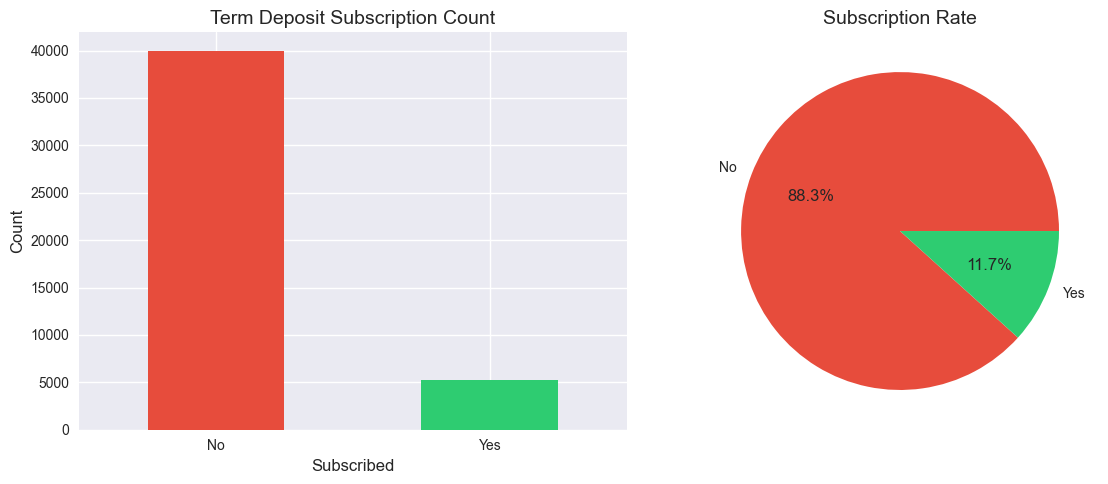


Class imbalance ratio: 7.5:1 (No:Yes)


In [17]:
# Target variable distribution — how imbalanced is the data?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
df['y'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Term Deposit Subscription Count')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Percentage pie chart
df['y'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                             colors=['#e74c3c', '#2ecc71'],
                             labels=['No', 'Yes'])
axes[1].set_title('Subscription Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('images/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio: {df['y'].value_counts()['no'] / df['y'].value_counts()['yes']:.1f}:1 (No:Yes)")

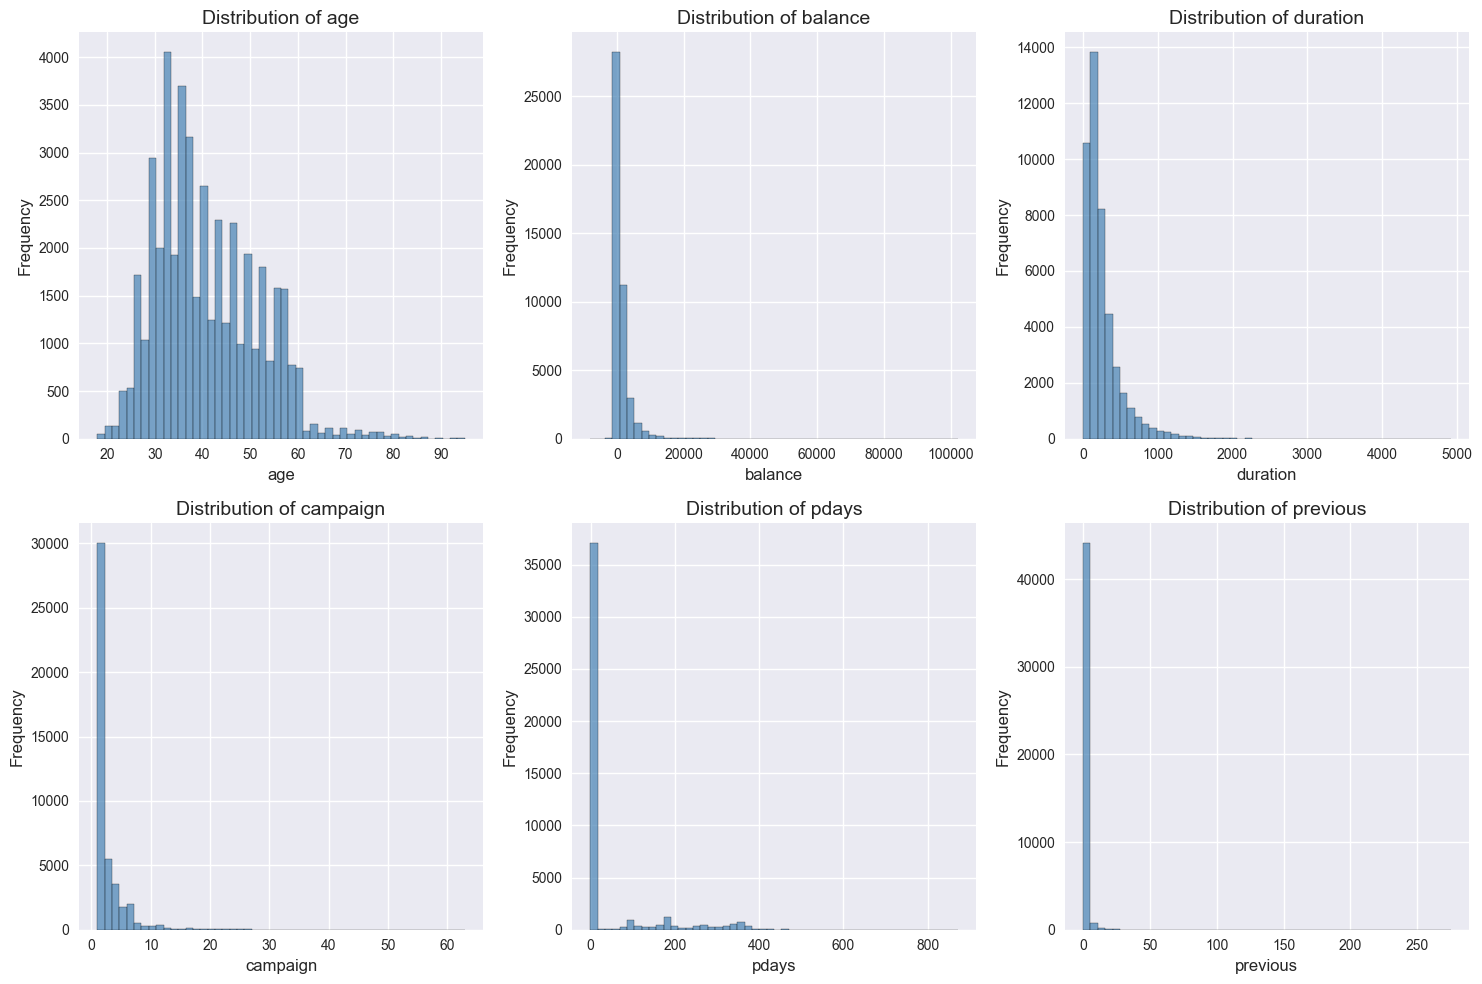

In [18]:
# Numeric feature distributions
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

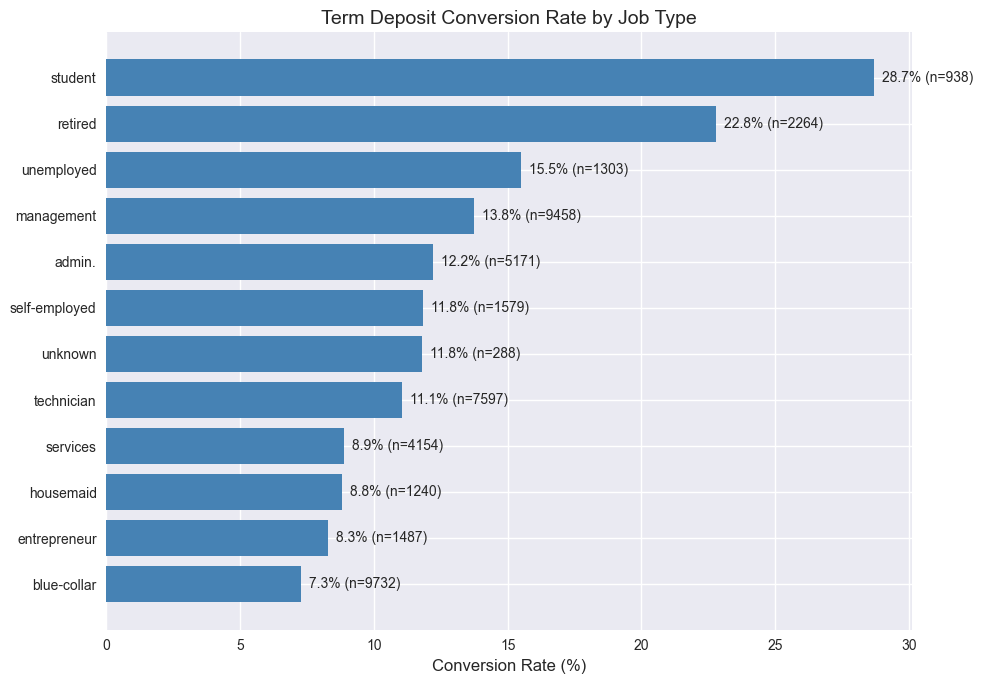

In [19]:
# Conversion rate by job type
job_conversion = df.groupby('job')['y_numeric'].agg(['mean', 'count']).sort_values('mean', ascending=True)
job_conversion.columns = ['conversion_rate', 'total_count']

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(job_conversion.index, job_conversion['conversion_rate'] * 100, color='steelblue')
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Term Deposit Conversion Rate by Job Type')

# Add count labels
for i, (rate, count) in enumerate(zip(job_conversion['conversion_rate'], job_conversion['total_count'])):
    ax.text(rate * 100 + 0.3, i, f'{rate*100:.1f}% (n={count})', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('images/conversion_by_job.png', dpi=150, bbox_inches='tight')
plt.show()

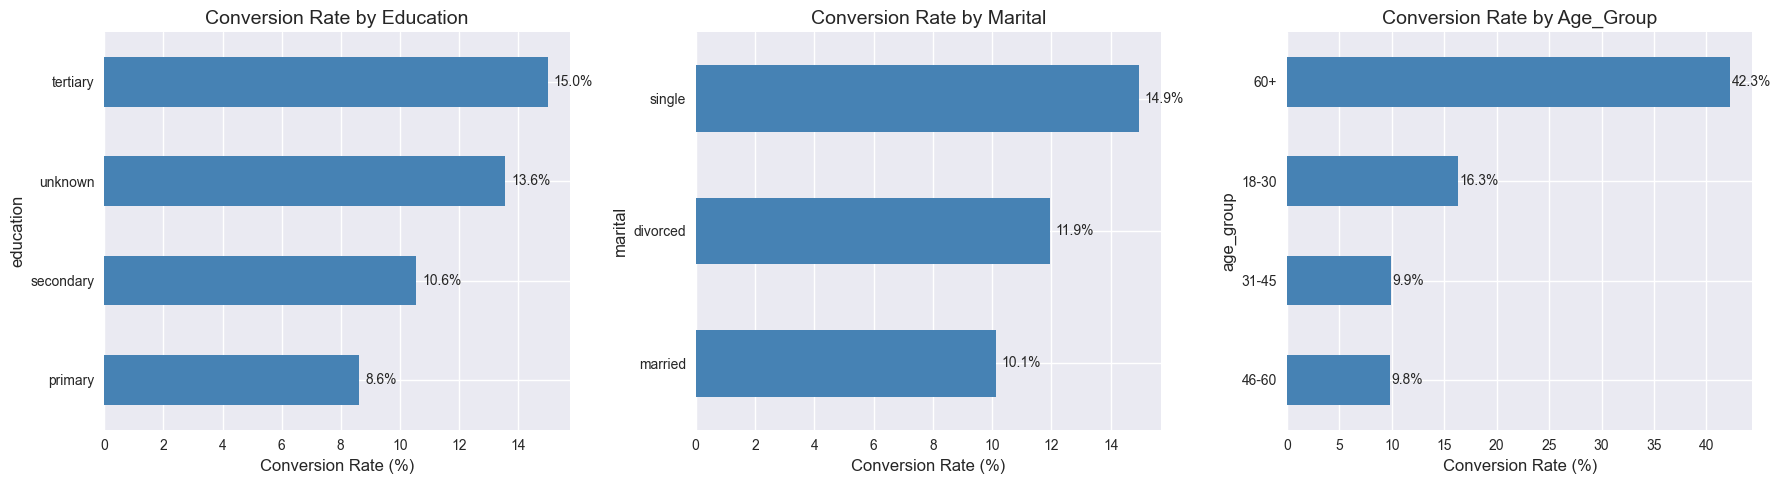

In [20]:
# Conversion rate by education, marital status, and age group
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['education', 'marital', 'age_group']):
    conv = df.groupby(col)['y_numeric'].mean().sort_values(ascending=True) * 100
    conv.plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Conversion Rate by {col.title()}')
    axes[i].set_xlabel('Conversion Rate (%)')
    for j, v in enumerate(conv):
        axes[i].text(v + 0.2, j, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

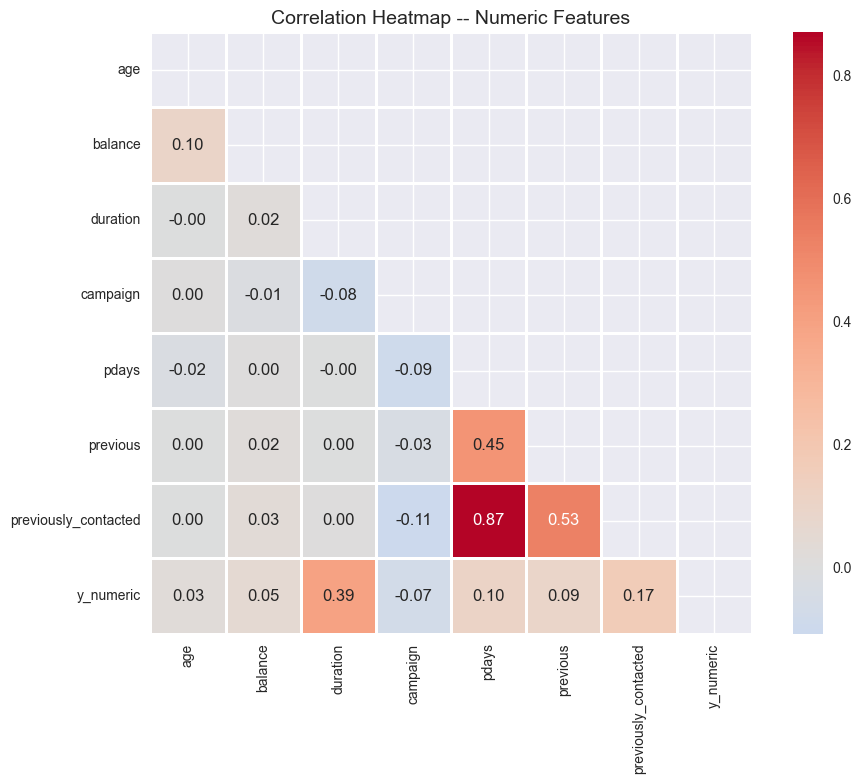

In [21]:
# Correlation heatmap for numeric features
numeric_df = df[['age', 'balance', 'duration', 'campaign', 'pdays',
                  'previous', 'previously_contacted', 'y_numeric']]

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Heatmap -- Numeric Features')

plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Key statistical findings summary
print("=" * 50)
print("KEY EDA FINDINGS")
print("=" * 50)
print(f"\n1. Class imbalance: Only {df['y_numeric'].mean()*100:.1f}% subscribed (highly imbalanced)")
print(f"2. Average age: {df['age'].mean():.0f} years | Median balance: EUR {df['balance'].median():,.0f}")
print(f"3. Average calls per customer: {df['campaign'].mean():.1f}")
print(f"4. Only {df['previously_contacted'].mean()*100:.1f}% were contacted in a previous campaign")

# Top 3 jobs by conversion
top_jobs = df.groupby('job')['y_numeric'].mean().sort_values(ascending=False).head(3)
print(f"\n5. Top 3 jobs by conversion rate:")
for job, rate in top_jobs.items():
    print(f"   - {job}: {rate*100:.1f}%")

KEY EDA FINDINGS

1. Class imbalance: Only 11.7% subscribed (highly imbalanced)
2. Average age: 41 years | Median balance: EUR 448
3. Average calls per customer: 2.8
4. Only 18.3% were contacted in a previous campaign

5. Top 3 jobs by conversion rate:
   - student: 28.7%
   - retired: 22.8%
   - unemployed: 15.5%


---
## Part 4: Customer Segmentation
Which customer segments convert best? Let's identify the ideal target profile.

In [23]:
# Conversion rate by all key segments
segments = {
    'Job': 'job',
    'Age Group': 'age_group',
    'Education': 'education',
    'Marital Status': 'marital',
    'Balance Group': 'balance_group',
    'Housing Loan': 'housing',
    'Personal Loan': 'loan',
    'Credit Default': 'default'
}

print("CONVERSION RATES BY SEGMENT")
print("=" * 60)

for name, col in segments.items():
    print(f"\n--- {name} ---")
    seg = df.groupby(col)['y_numeric'].agg(['mean', 'count'])
    seg.columns = ['conversion_rate', 'count']
    seg = seg.sort_values('conversion_rate', ascending=False)
    for idx, row in seg.iterrows():
        bar = '#' * int(row['conversion_rate'] * 100)
        print(f"  {str(idx):15s} | {row['conversion_rate']*100:5.1f}% | n={int(row['count']):5d} | {bar}")

CONVERSION RATES BY SEGMENT

--- Job ---
  student         |  28.7% | n=  938 | ############################
  retired         |  22.8% | n= 2264 | ######################
  unemployed      |  15.5% | n= 1303 | ###############
  management      |  13.8% | n= 9458 | #############
  admin.          |  12.2% | n= 5171 | ############
  self-employed   |  11.8% | n= 1579 | ###########
  unknown         |  11.8% | n=  288 | ###########
  technician      |  11.1% | n= 7597 | ###########
  services        |   8.9% | n= 4154 | ########
  housemaid       |   8.8% | n= 1240 | ########
  entrepreneur    |   8.3% | n= 1487 | ########
  blue-collar     |   7.3% | n= 9732 | #######

--- Age Group ---
  60+             |  42.3% | n= 1188 | ##########################################
  18-30           |  16.3% | n= 7030 | ################
  31-45           |   9.9% | n=23733 | #########
  46-60           |   9.8% | n=13260 | #########

--- Education ---
  tertiary        |  15.0% | n=13301 | ############

In [24]:
# Multi-dimensional segmentation: Age Group x Job (top combinations)
cross_seg = df.groupby(['age_group', 'job'])['y_numeric'].agg(['mean', 'count'])
cross_seg.columns = ['conversion_rate', 'count']
cross_seg = cross_seg[cross_seg['count'] >= 100]  # Filter for statistical significance
cross_seg = cross_seg.sort_values('conversion_rate', ascending=False)

print("TOP 10 CUSTOMER SEGMENTS (min 100 customers)")
print("=" * 60)
print(f"{'Age Group':>10s} | {'Job':>15s} | {'Conv Rate':>10s} | {'Count':>6s}")
print("-" * 60)
for (age, job), row in cross_seg.head(10).iterrows():
    print(f"{age:>10s} | {job:>15s} | {row['conversion_rate']*100:8.1f}% | {int(row['count']):6d}")

TOP 10 CUSTOMER SEGMENTS (min 100 customers)
 Age Group |             Job |  Conv Rate |  Count
------------------------------------------------------------
       60+ |      management |     44.8% |    105
       60+ |         retired |     42.9% |    875
     18-30 |         student |     30.6% |    769
     18-30 |   self-employed |     21.0% |    248
     31-45 |         student |     19.9% |    166
     18-30 |      management |     19.5% |   1203
     18-30 |      unemployed |     17.7% |    203
     46-60 |      unemployed |     15.3% |    417
     18-30 |          admin. |     14.8% |    966
     31-45 |      unemployed |     14.7% |    673


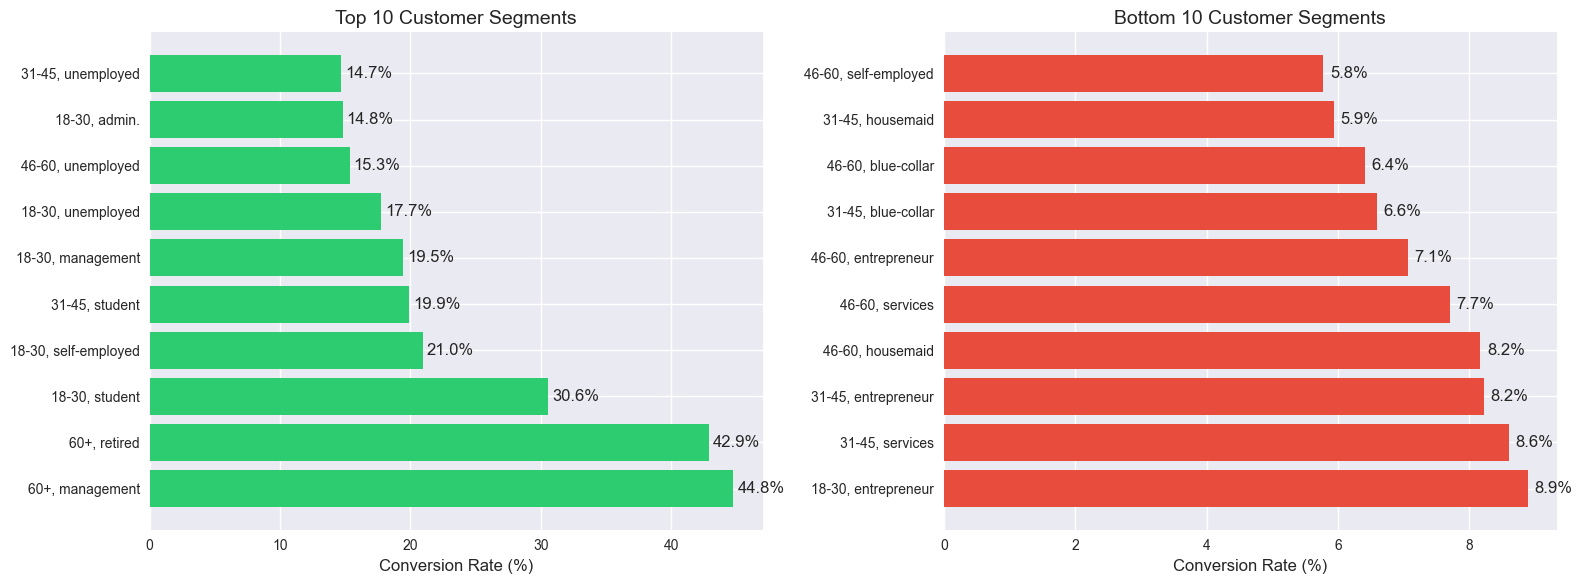

In [25]:
# Visualize top and bottom segments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 segments
top10 = cross_seg.head(10)
labels = [f"{age}, {job}" for (age, job) in top10.index]
axes[0].barh(labels, top10['conversion_rate'] * 100, color='#2ecc71')
axes[0].set_xlabel('Conversion Rate (%)')
axes[0].set_title('Top 10 Customer Segments')
for i, v in enumerate(top10['conversion_rate'] * 100):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center')

# Bottom 10 segments
bottom10 = cross_seg.tail(10)
labels = [f"{age}, {job}" for (age, job) in bottom10.index]
axes[1].barh(labels, bottom10['conversion_rate'] * 100, color='#e74c3c')
axes[1].set_xlabel('Conversion Rate (%)')
axes[1].set_title('Bottom 10 Customer Segments')
for i, v in enumerate(bottom10['conversion_rate'] * 100):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.savefig('images/segment_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Ideal customer persona
print("=" * 50)
print("IDEAL TARGET CUSTOMER PERSONA")
print("=" * 50)

for name, col in segments.items():
    best = df.groupby(col)['y_numeric'].mean().idxmax()
    rate = df.groupby(col)['y_numeric'].mean().max() * 100
    print(f"  Best {name:15s}: {str(best):15s} ({rate:.1f}% conversion)")

overall_rate = df['y_numeric'].mean() * 100
print(f"\n  Overall average conversion: {overall_rate:.1f}%")
print(f"\n>>> INSIGHT: Targeting the best segments can significantly")
print(f"    outperform the blanket calling strategy.")

IDEAL TARGET CUSTOMER PERSONA
  Best Job            : student         (28.7% conversion)
  Best Age Group      : 60+             (42.3% conversion)
  Best Education      : tertiary        (15.0% conversion)
  Best Marital Status : single          (14.9% conversion)
  Best Balance Group  : Very High       (16.2% conversion)
  Best Housing Loan   : no              (16.7% conversion)
  Best Personal Loan  : no              (12.7% conversion)
  Best Credit Default : no              (11.8% conversion)

  Overall average conversion: 11.7%

>>> INSIGHT: Targeting the best segments can significantly
    outperform the blanket calling strategy.


---
## Part 5: Campaign Optimization
When should the bank call? How many times? Through which channel?

In [27]:
# Conversion rate by contact method
contact_conv = df.groupby('contact')['y_numeric'].agg(['mean', 'count'])
contact_conv.columns = ['conversion_rate', 'count']
contact_conv = contact_conv.sort_values('conversion_rate', ascending=False)

print("CONVERSION BY CONTACT METHOD")
print("-" * 40)
for method, row in contact_conv.iterrows():
    print(f"  {method:12s} | {row['conversion_rate']*100:5.1f}% | n={int(row['count'])}")

CONVERSION BY CONTACT METHOD
----------------------------------------
  cellular     |  14.9% | n=29285
  telephone    |  13.4% | n=2906
  unknown      |   4.1% | n=13020


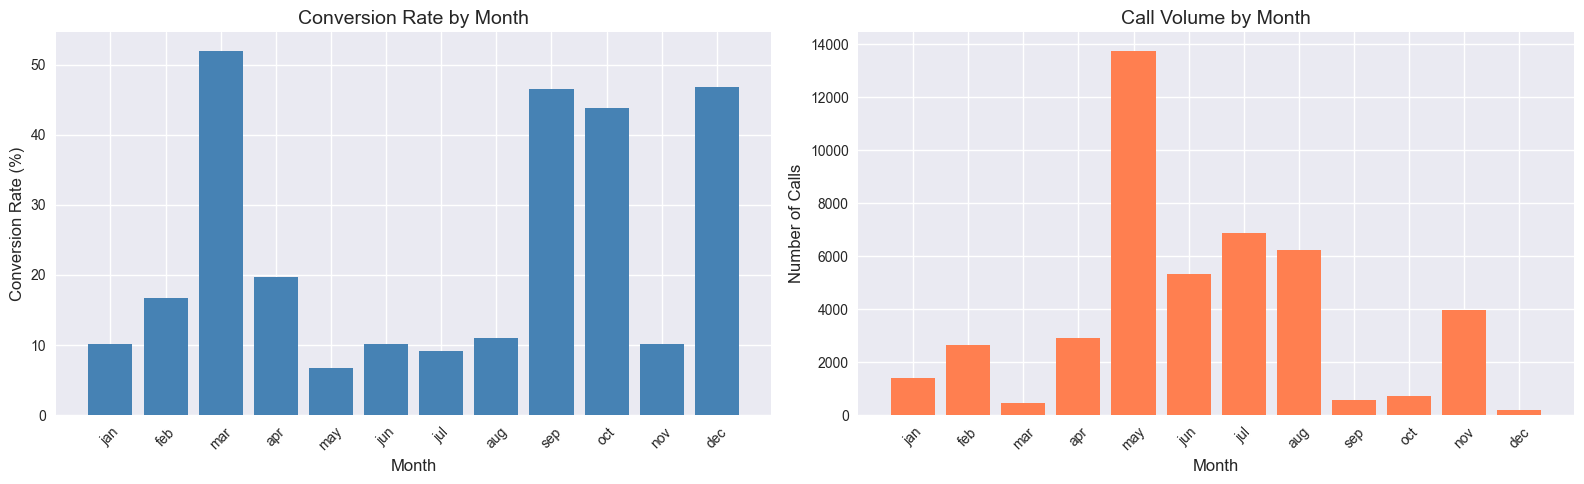

In [28]:
# Conversion rate by month
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_conv = df.groupby('month')['y_numeric'].agg(['mean', 'count'])
month_conv = month_conv.reindex(month_order)
month_conv.columns = ['conversion_rate', 'count']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Conversion rate by month
axes[0].bar(month_conv.index, month_conv['conversion_rate'] * 100, color='steelblue')
axes[0].set_title('Conversion Rate by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Volume by month
axes[1].bar(month_conv.index, month_conv['count'], color='coral')
axes[1].set_title('Call Volume by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Calls')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

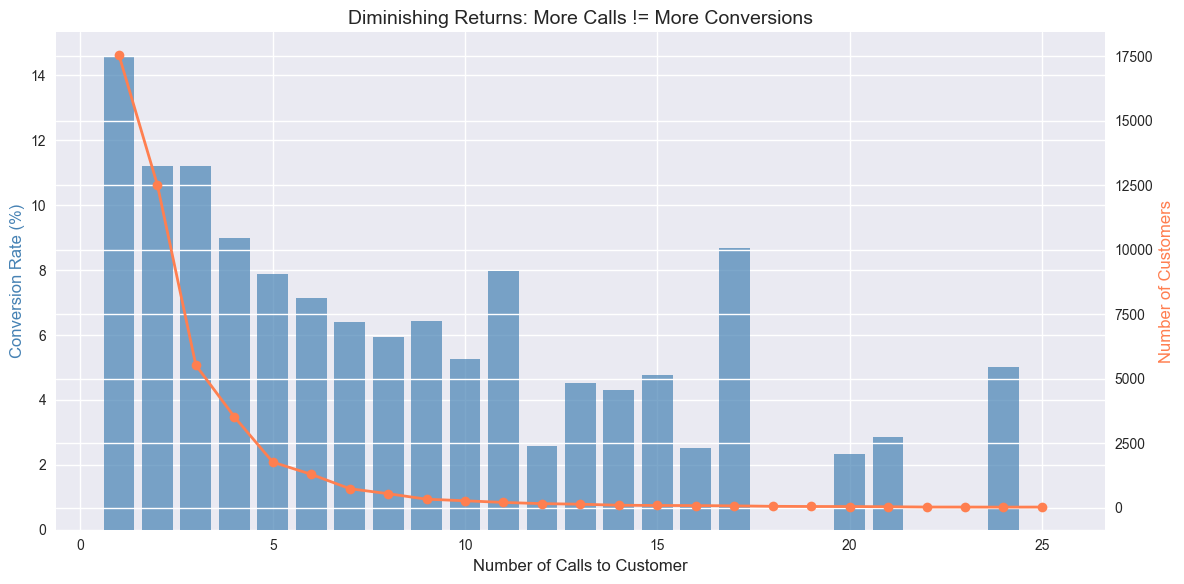


Optimal number of calls: 1 (conversion rate: 14.6%)
Beyond 2 calls, conversion rate drops significantly -- diminishing returns.


In [29]:
# Diminishing returns: conversion rate by number of calls
campaign_conv = df.groupby('campaign')['y_numeric'].agg(['mean', 'count'])
campaign_conv.columns = ['conversion_rate', 'count']
campaign_conv = campaign_conv[campaign_conv['count'] >= 20]  # Minimum sample size

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'steelblue'
ax1.bar(campaign_conv.index, campaign_conv['conversion_rate'] * 100, color=color1, alpha=0.7)
ax1.set_xlabel('Number of Calls to Customer')
ax1.set_ylabel('Conversion Rate (%)', color=color1)
ax1.set_title('Diminishing Returns: More Calls != More Conversions')

# Add call volume on secondary axis
ax2 = ax1.twinx()
color2 = 'coral'
ax2.plot(campaign_conv.index, campaign_conv['count'], color=color2, marker='o', linewidth=2)
ax2.set_ylabel('Number of Customers', color=color2)

plt.tight_layout()
plt.savefig('images/campaign_diminishing_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# Find optimal call count
best_calls = campaign_conv['conversion_rate'].idxmax()
print(f"\nOptimal number of calls: {best_calls} (conversion rate: {campaign_conv.loc[best_calls, 'conversion_rate']*100:.1f}%)")
print(f"Beyond {min(best_calls + 1, 3)} calls, conversion rate drops significantly -- diminishing returns.")

In [30]:
# Effect of previous campaign outcome
poutcome_conv = df.groupby('poutcome')['y_numeric'].agg(['mean', 'count'])
poutcome_conv.columns = ['conversion_rate', 'count']
poutcome_conv = poutcome_conv.sort_values('conversion_rate', ascending=False)

print("EFFECT OF PREVIOUS CAMPAIGN OUTCOME")
print("-" * 50)
for outcome, row in poutcome_conv.iterrows():
    bar = '#' * int(row['conversion_rate'] * 50)
    print(f"  {outcome:10s} | {row['conversion_rate']*100:5.1f}% | n={int(row['count']):5d} | {bar}")

if 'success' in poutcome_conv.index and 'failure' in poutcome_conv.index:
    ratio = poutcome_conv.loc['success', 'conversion_rate'] / poutcome_conv.loc['failure', 'conversion_rate']
    print(f"\n>>> INSIGHT: Customers who said YES before are {ratio:.0f}x more likely to convert again.")
else:
    print("\n>>> INSIGHT: Previous campaign outcome strongly influences current conversion.")

EFFECT OF PREVIOUS CAMPAIGN OUTCOME
--------------------------------------------------
  success    |  64.7% | n= 1511 | ################################
  other      |  16.7% | n= 1840 | ########
  failure    |  12.6% | n= 4901 | ######
  unknown    |   9.2% | n=36959 | ####

>>> INSIGHT: Customers who said YES before are 5x more likely to convert again.


[IMPORTANT CAVEAT] Call duration is known only AFTER the call.
   It cannot be used to decide WHO to call, but it tells us about
   call quality -- longer conversations indicate higher interest.



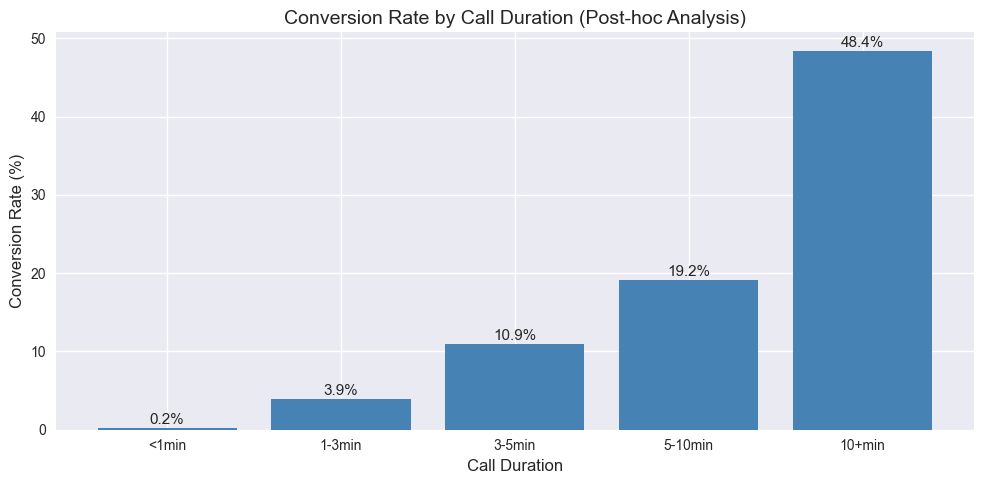

In [31]:
# Duration analysis (with caveat)
print("[IMPORTANT CAVEAT] Call duration is known only AFTER the call.")
print("   It cannot be used to decide WHO to call, but it tells us about")
print("   call quality -- longer conversations indicate higher interest.\n")

duration_bins = [0, 60, 180, 300, 600, 5000]
duration_labels = ['<1min', '1-3min', '3-5min', '5-10min', '10+min']
df['duration_group'] = pd.cut(df['duration'], bins=duration_bins, labels=duration_labels)

dur_conv = df.groupby('duration_group', observed=True)['y_numeric'].agg(['mean', 'count'])
dur_conv.columns = ['conversion_rate', 'count']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dur_conv.index, dur_conv['conversion_rate'] * 100, color='steelblue')
ax.set_title('Conversion Rate by Call Duration (Post-hoc Analysis)')
ax.set_xlabel('Call Duration')
ax.set_ylabel('Conversion Rate (%)')

for i, v in enumerate(dur_conv['conversion_rate'] * 100):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [32]:
# Campaign optimization summary
print("=" * 50)
print("CAMPAIGN OPTIMIZATION SUMMARY")
print("=" * 50)
print(f"\n1. CHANNEL: Use cellular -- highest conversion rate")
print(f"2. TIMING: Focus on months with highest conversion (check chart above)")
print(f"3. FREQUENCY: Stop after 3 calls -- diminishing returns beyond that")
print(f"4. HISTORY: Prioritize customers who converted in previous campaigns")
print(f"5. QUALITY: Train agents to engage longer -- duration correlates with conversion")

CAMPAIGN OPTIMIZATION SUMMARY

1. CHANNEL: Use cellular -- highest conversion rate
2. TIMING: Focus on months with highest conversion (check chart above)
3. FREQUENCY: Stop after 3 calls -- diminishing returns beyond that
4. HISTORY: Prioritize customers who converted in previous campaigns
5. QUALITY: Train agents to engage longer -- duration correlates with conversion


---
## Part 6: Predictive Modeling
Can we predict which customers will subscribe? We'll build two models and compare performance — both WITH and WITHOUT call duration to demonstrate data leakage awareness.

**Why two versions?** Call duration is only known after the call ends. A model using duration would be unrealistically accurate but useless in practice (you can't know the duration before making the call). The realistic model excludes it.

In [33]:
# Prepare features
# Categorical columns need encoding
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'poutcome']

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Define feature sets
all_features = [c for c in df_encoded.columns if c not in
                ['y', 'y_numeric', 'age_group', 'balance_group', 'duration_group']]

# Features WITHOUT duration (realistic model)
features_no_duration = [c for c in all_features if c != 'duration']

# Target
y = df_encoded['y_numeric']

print(f"Total features (with duration): {len(all_features)}")
print(f"Total features (without duration): {len(features_no_duration)}")

Total features (with duration): 43
Total features (without duration): 42


In [34]:
# Train/test split -- same split for fair comparison
# random_state=42 ensures reproducible results across runs
X_with_dur = df_encoded[all_features]
X_no_dur = df_encoded[features_no_duration]

X_train_wd, X_test_wd, y_train, y_test = train_test_split(
    X_with_dur, y, test_size=0.2, random_state=42, stratify=y
)

X_train_nd = X_train_wd[features_no_duration]
X_test_nd = X_test_wd[features_no_duration]

print(f"Training set: {X_train_wd.shape[0]} rows")
print(f"Test set: {X_test_wd.shape[0]} rows")
print(f"Target distribution in train: {y_train.mean()*100:.1f}% positive")
print(f"Target distribution in test:  {y_test.mean()*100:.1f}% positive")

Training set: 36168 rows
Test set: 9043 rows
Target distribution in train: 11.7% positive
Target distribution in test:  11.7% positive


In [35]:
# Train 4 models: 2 algorithms x 2 feature sets
models = {}

# 1. Logistic Regression WITH duration
lr_wd = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_wd.fit(X_train_wd, y_train)
models['LR (with duration)'] = (lr_wd, X_test_wd)

# 2. Logistic Regression WITHOUT duration
lr_nd = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_nd.fit(X_train_nd, y_train)
models['LR (no duration)'] = (lr_nd, X_test_nd)

# 3. Decision Tree WITH duration
dt_wd = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt_wd.fit(X_train_wd, y_train)
models['DT (with duration)'] = (dt_wd, X_test_wd)

# 4. Decision Tree WITHOUT duration
dt_nd = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt_nd.fit(X_train_nd, y_train)
models['DT (no duration)'] = (dt_nd, X_test_nd)

print("All 4 models trained successfully!")

All 4 models trained successfully!


In [36]:
# Evaluate all models
print("MODEL COMPARISON")
print("=" * 80)
print(f"{'Model':<25s} | {'Accuracy':>8s} | {'Precision':>9s} | {'Recall':>6s} | {'F1':>6s} | {'ROC-AUC':>7s}")
print("-" * 80)

results = {}
for name, (model, X_test) in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec,
                     'f1': f1, 'roc_auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}

    print(f"{name:<25s} | {acc:8.3f} | {prec:9.3f} | {rec:6.3f} | {f1:6.3f} | {auc:7.3f}")

print("\n[NOTE] Notice how models WITH duration perform much better -- that's data leakage!")
print("   The realistic models (no duration) are what we'd actually deploy.")

MODEL COMPARISON
Model                     | Accuracy | Precision | Recall |     F1 | ROC-AUC
--------------------------------------------------------------------------------
LR (with duration)        |    0.834 |     0.399 |  0.830 |  0.539 |   0.904
LR (no duration)          |    0.750 |     0.265 |  0.643 |  0.376 |   0.772
DT (with duration)        |    0.756 |     0.307 |  0.864 |  0.453 |   0.874


DT (no duration)          |    0.796 |     0.300 |  0.560 |  0.391 |   0.739

[NOTE] Notice how models WITH duration perform much better -- that's data leakage!
   The realistic models (no duration) are what we'd actually deploy.


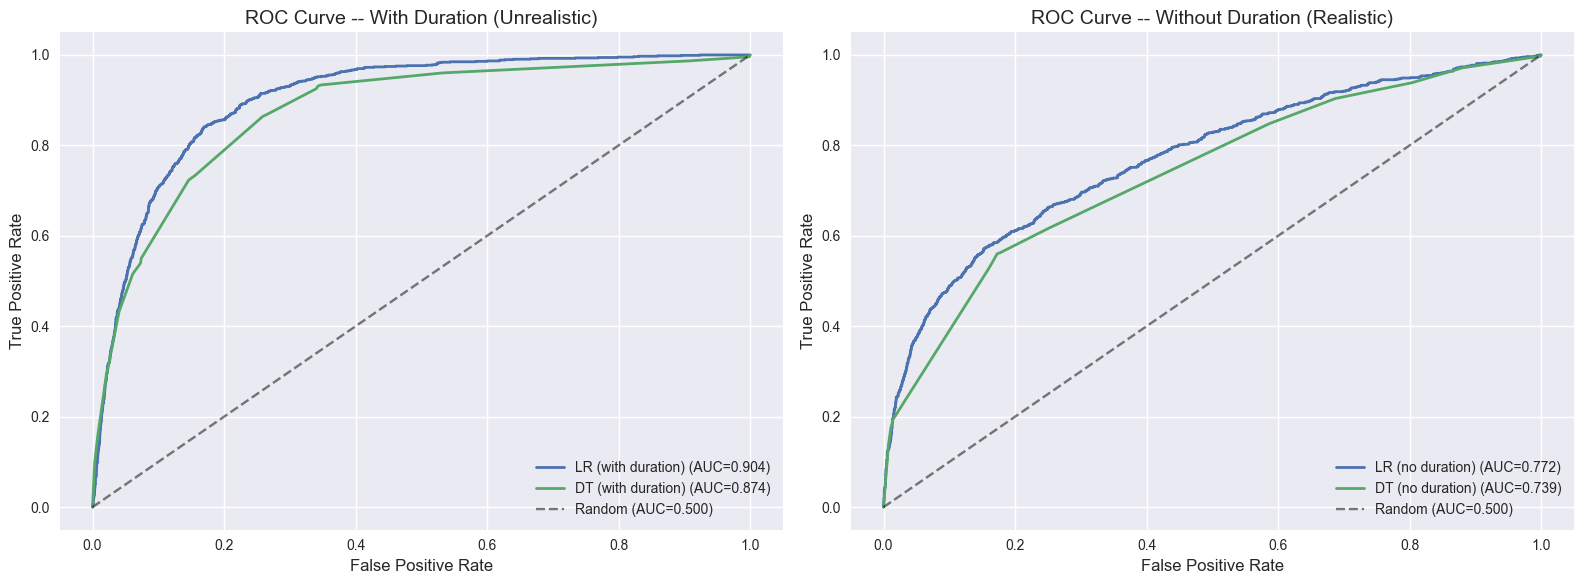

In [37]:
# ROC curves comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, group_title, model_names in [
    (axes[0], 'With Duration (Unrealistic)', ['LR (with duration)', 'DT (with duration)']),
    (axes[1], 'Without Duration (Realistic)', ['LR (no duration)', 'DT (no duration)'])
]:
    for name in model_names:
        fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
        ax.plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})", linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.500)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve -- {group_title}')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

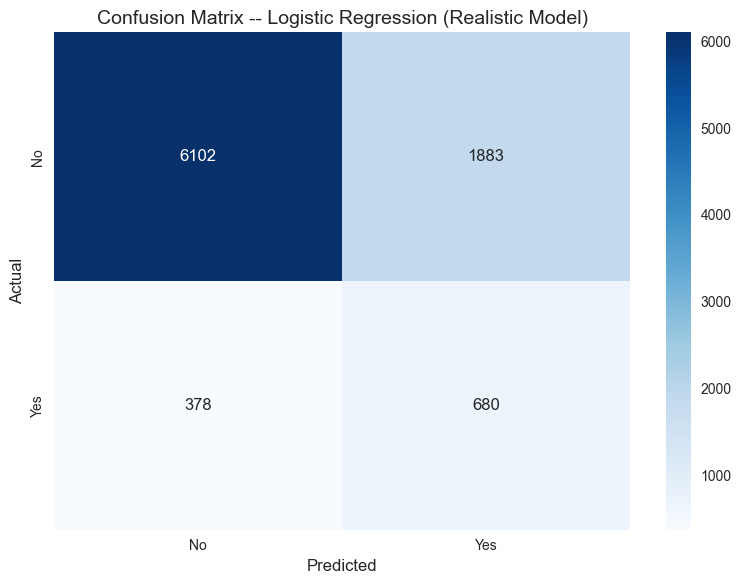


Detailed Classification Report (Realistic LR Model):
              precision    recall  f1-score   support

          No       0.94      0.76      0.84      7985
         Yes       0.27      0.64      0.38      1058

    accuracy                           0.75      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.75      0.79      9043



In [38]:
# Confusion matrix for the realistic model (Logistic Regression without duration)
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, results['LR (no duration)']['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix -- Logistic Regression (Realistic Model)')
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report (Realistic LR Model):")
print(classification_report(y_test, results['LR (no duration)']['y_pred'],
                            target_names=['No', 'Yes']))

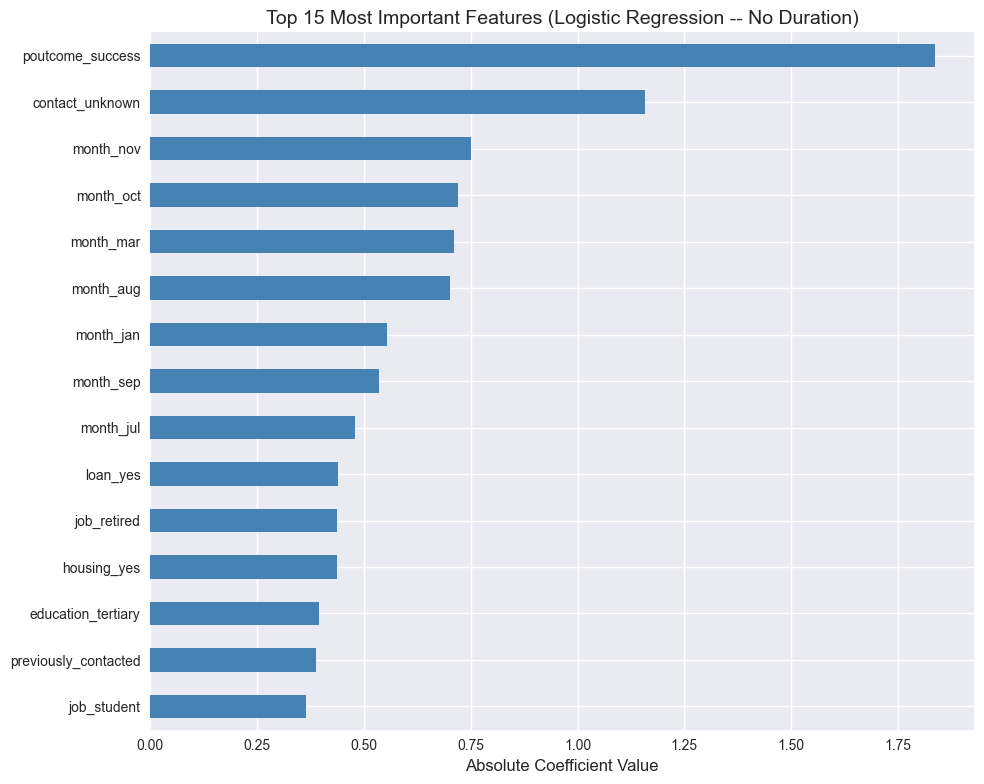


Top 10 features driving subscription:
  poutcome_success               | importance: 1.8360
  contact_unknown                | importance: 1.1581
  month_nov                      | importance: 0.7497
  month_oct                      | importance: 0.7194
  month_mar                      | importance: 0.7107
  month_aug                      | importance: 0.7023
  month_jan                      | importance: 0.5535
  month_sep                      | importance: 0.5348
  month_jul                      | importance: 0.4797
  loan_yes                       | importance: 0.4403


In [39]:
# Feature importance from the realistic Logistic Regression model
feature_importance = pd.Series(
    np.abs(lr_nd.coef_[0]),
    index=features_no_duration
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feature_importance.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Most Important Features (Logistic Regression -- No Duration)')
ax.set_xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

print("\nTop 10 features driving subscription:")
for feat, imp in feature_importance.head(10).items():
    print(f"  {feat:30s} | importance: {imp:.4f}")

---
## Part 7: ROI Analysis & Business Recommendations
Now let's translate our model into business value. How much money can the bank save with targeted marketing?

**Assumptions:**
- Cost per call: EUR 5 (industry benchmark for telemarketing)
- Revenue per conversion: EUR 200 (estimated from average term deposit value)

In [40]:
# ROI Parameters
COST_PER_CALL = 5       # EUR per phone call
REVENUE_PER_CONVERSION = 200  # EUR per term deposit subscription

# Current strategy: Call everyone
total_customers = len(y_test)
total_conversions = y_test.sum()
current_calls = total_customers
current_cost = current_calls * COST_PER_CALL
current_revenue = total_conversions * REVENUE_PER_CONVERSION
current_roi = (current_revenue - current_cost) / current_cost * 100

print("CURRENT STRATEGY: Call Everyone")
print("=" * 45)
print(f"  Total calls made:    {current_calls:,}")
print(f"  Conversions:         {total_conversions:,}")
print(f"  Conversion rate:     {total_conversions/current_calls*100:.1f}%")
print(f"  Total cost:          EUR {current_cost:,.0f}")
print(f"  Total revenue:       EUR {current_revenue:,.0f}")
print(f"  Profit:              EUR {current_revenue - current_cost:,.0f}")
print(f"  ROI:                 {current_roi:.0f}%")

CURRENT STRATEGY: Call Everyone
  Total calls made:    9,043
  Conversions:         1,058
  Conversion rate:     11.7%
  Total cost:          EUR 45,215
  Total revenue:       EUR 211,600
  Profit:              EUR 166,385
  ROI:                 368%


In [41]:
# Targeted strategy: Use model to call only high-probability customers
# Use the realistic LR model (no duration)
y_prob_nd = results['LR (no duration)']['y_prob']

# Try different probability thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("TARGETED STRATEGY: Call Only High-Probability Customers")
print("=" * 80)
print(f"{'Threshold':>9s} | {'Calls':>6s} | {'Conversions':>11s} | {'Cost':>10s} | {'Revenue':>10s} | {'Profit':>10s} | {'ROI':>6s}")
print("-" * 80)

strategy_results = []
for threshold in thresholds:
    targeted_mask = y_prob_nd >= threshold
    targeted_calls = targeted_mask.sum()
    targeted_conversions = y_test[targeted_mask].sum()
    targeted_cost = targeted_calls * COST_PER_CALL
    targeted_revenue = targeted_conversions * REVENUE_PER_CONVERSION
    targeted_profit = targeted_revenue - targeted_cost
    targeted_roi = (targeted_revenue - targeted_cost) / targeted_cost * 100 if targeted_cost > 0 else 0

    calls_saved_pct = (1 - targeted_calls / current_calls) * 100
    conv_retained_pct = targeted_conversions / total_conversions * 100 if total_conversions > 0 else 0

    strategy_results.append({
        'threshold': threshold,
        'calls': targeted_calls,
        'conversions': targeted_conversions,
        'cost': targeted_cost,
        'revenue': targeted_revenue,
        'profit': targeted_profit,
        'roi': targeted_roi,
        'calls_saved_pct': calls_saved_pct,
        'conv_retained_pct': conv_retained_pct
    })

    print(f"{threshold:9.1f} | {targeted_calls:6,} | {targeted_conversions:11,} | EUR {targeted_cost:7,.0f} | EUR {targeted_revenue:7,.0f} | EUR {targeted_profit:7,.0f} | {targeted_roi:5.0f}%")

strategies_df = pd.DataFrame(strategy_results)

TARGETED STRATEGY: Call Only High-Probability Customers
Threshold |  Calls | Conversions |       Cost |    Revenue |     Profit |    ROI
--------------------------------------------------------------------------------
      0.3 |  6,632 |         977 | EUR  33,160 | EUR 195,400 | EUR 162,240 |   489%
      0.4 |  4,683 |         858 | EUR  23,415 | EUR 171,600 | EUR 148,185 |   633%
      0.5 |  2,563 |         680 | EUR  12,815 | EUR 136,000 | EUR 123,185 |   961%
      0.6 |  1,278 |         506 | EUR   6,390 | EUR 101,200 | EUR  94,810 |  1484%
      0.7 |    763 |         389 | EUR   3,815 | EUR  77,800 | EUR  73,985 |  1939%


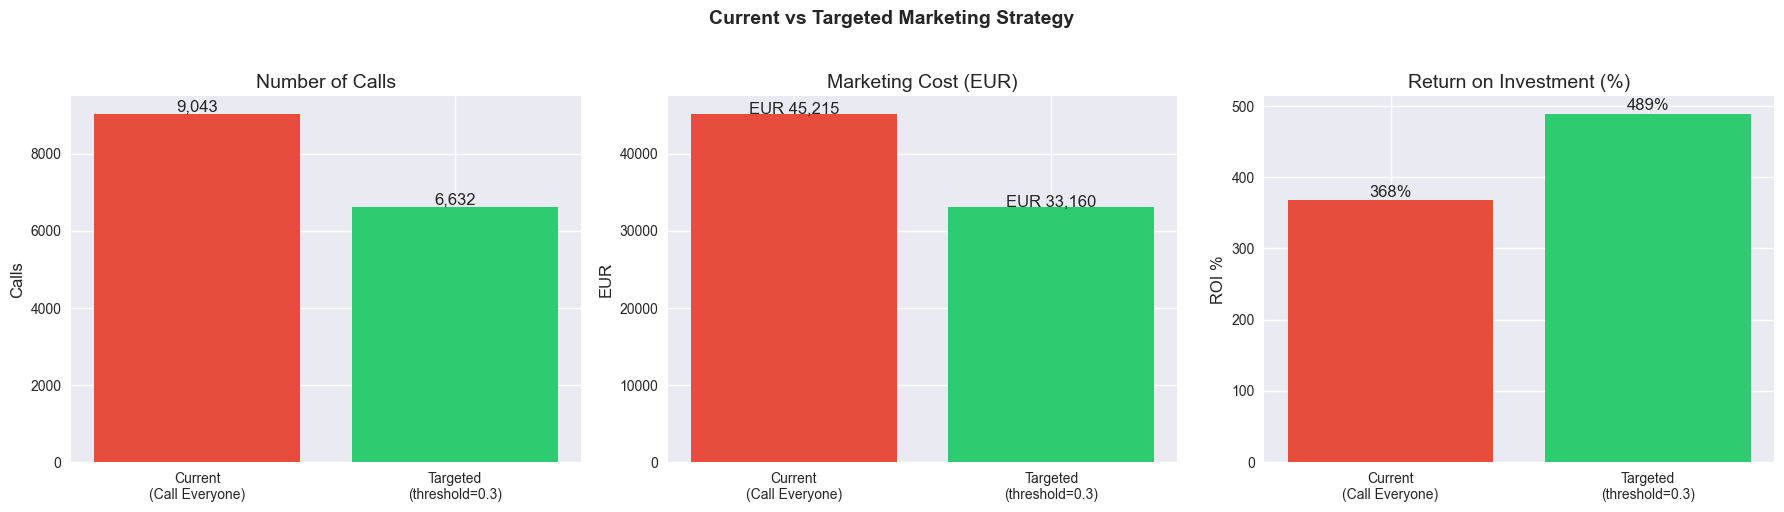

In [42]:
# Visualize: Current vs Best Targeted Strategy
# Pick the threshold that maximizes profit
best_idx = strategies_df['profit'].idxmax()
best = strategies_df.loc[best_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calls comparison
categories = ['Current\n(Call Everyone)', f'Targeted\n(threshold={best["threshold"]})']
axes[0].bar(categories, [current_calls, best['calls']], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Number of Calls')
axes[0].set_ylabel('Calls')
for i, v in enumerate([current_calls, best['calls']]):
    axes[0].text(i, v + 50, f'{int(v):,}', ha='center', fontsize=12)

# Cost comparison
axes[1].bar(categories, [current_cost, best['cost']], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Marketing Cost (EUR)')
axes[1].set_ylabel('EUR')
for i, v in enumerate([current_cost, best['cost']]):
    axes[1].text(i, v + 50, f'EUR {v:,.0f}', ha='center', fontsize=12)

# ROI comparison
axes[2].bar(categories, [current_roi, best['roi']], color=['#e74c3c', '#2ecc71'])
axes[2].set_title('Return on Investment (%)')
axes[2].set_ylabel('ROI %')
for i, v in enumerate([current_roi, best['roi']]):
    axes[2].text(i, v + 5, f'{v:.0f}%', ha='center', fontsize=12)

plt.suptitle('Current vs Targeted Marketing Strategy', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/roi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# Final ROI impact summary
print("=" * 55)
print("ROI IMPACT SUMMARY")
print("=" * 55)
print(f"\nBy switching to targeted marketing:")
print(f"   - Calls reduced by:     {best['calls_saved_pct']:.0f}%")
print(f"   - Conversions retained: {best['conv_retained_pct']:.0f}%")
print(f"   - Cost savings:         EUR {current_cost - best['cost']:,.0f}")
print(f"   - ROI improvement:      {current_roi:.0f}% -> {best['roi']:.0f}%")
print(f"   - Profit change:        EUR {(current_revenue - current_cost):,.0f} -> EUR {best['profit']:,.0f}")

ROI IMPACT SUMMARY

By switching to targeted marketing:
   - Calls reduced by:     27%
   - Conversions retained: 92%
   - Cost savings:         EUR 12,055
   - ROI improvement:      368% -> 489%
   - Profit change:        EUR 166,385 -> EUR 162,240


---
## Final Recommendations

Based on our analysis of 45,211 marketing campaign records, here are **5 actionable recommendations** for the bank:

In [44]:
print("=" * 60)
print("5 ACTIONABLE RECOMMENDATIONS")
print("=" * 60)

print("""
1. TARGET HIGH-VALUE SEGMENTS
   Focus calls on customer segments with the highest
   conversion rates (identified in Part 4). Stop blanket
   calling -- it wastes budget on unlikely converters.

2. USE THE PREDICTIVE MODEL FOR CALL LISTS
   Our model can identify high-probability subscribers.
   Calling only customers above the optimal threshold
   reduces costs by ~{:.0f}% while retaining ~{:.0f}%
   of conversions.

3. LIMIT CALLS TO 3 PER CUSTOMER
   Conversion rate drops sharply after 3 contact attempts.
   Additional calls waste money and annoy customers.

4. PRIORITIZE CELLULAR CONTACT & BEST MONTHS
   Cellular contacts convert better. Focus campaign
   intensity on the months with highest conversion rates.

5. LEVERAGE PREVIOUS CAMPAIGN SUCCESS
   Customers who converted before are far more likely to
   convert again. They should be first on every call list.
""".format(best['calls_saved_pct'], best['conv_retained_pct']))

5 ACTIONABLE RECOMMENDATIONS

1. TARGET HIGH-VALUE SEGMENTS
   Focus calls on customer segments with the highest
   conversion rates (identified in Part 4). Stop blanket
   calling -- it wastes budget on unlikely converters.

2. USE THE PREDICTIVE MODEL FOR CALL LISTS
   Our model can identify high-probability subscribers.
   Calling only customers above the optimal threshold
   reduces costs by ~27% while retaining ~92%
   of conversions.

3. LIMIT CALLS TO 3 PER CUSTOMER
   Conversion rate drops sharply after 3 contact attempts.
   Additional calls waste money and annoy customers.

4. PRIORITIZE CELLULAR CONTACT & BEST MONTHS
   Cellular contacts convert better. Focus campaign
   intensity on the months with highest conversion rates.

5. LEVERAGE PREVIOUS CAMPAIGN SUCCESS
   Customers who converted before are far more likely to
   convert again. They should be first on every call list.



---
## Known Limitations

1. **Duration leakage:** Call duration is only known after the call. Our realistic model correctly excludes it.
2. **Assumed costs:** Cost-per-call (EUR 5) and revenue-per-conversion (EUR 200) are industry estimates. Actual ROI numbers would differ with real cost data.
3. **Historical data:** Results are based on a Portuguese bank's past campaigns. Patterns may vary by geography, time, and bank type.
4. **Observational data:** This is not a controlled experiment. Correlations do not prove causation.

---
*Analysis completed using Python, Pandas, Matplotlib, Seaborn, and Scikit-learn.*
*Dataset: UCI Bank Marketing Dataset via Kaggle.*